<a href="https://colab.research.google.com/github/ShahAlam1219/PYTHON_FOR_DATA_SCIENCE/blob/main/Road_and_Street_Scene_Classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
!pip install timm ptflops grad-cam lime imagehash kagglehub scikit-image

  Using cached ptflops-0.7.5-py3-none-any.whl.metadata (9.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 26.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 30.7 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=10b567ae1f15298c770b5d6784b568d58c5e8974329b1ac194cd40d8378c39cf
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=69595946853abe006547311fee0679b4aa767b34927a615bb292e3a6313935e8
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
S

In [ ]:
!pip install imagehash

import os
import glob
import zipfile
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split

# 1. Unzip the uploaded archive
zip_path = "/content/archive (1).zip"
extract_dir = "/content/raw_data"

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

print(f"[*] Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("[*] Extraction complete.")

# 2. Audit and Deduplicate
PROCESSED_DIR = "/content/processed_data"
os.makedirs(PROCESSED_DIR, exist_ok=True)

all_images = glob.glob(os.path.join(extract_dir, "**", "*.jpg"), recursive=True) + \
             glob.glob(os.path.join(extract_dir, "**", "*.png"), recursive=True) + \
             glob.glob(os.path.join(extract_dir, "**", "*.jpeg"), recursive=True)

records = []
seen_hashes = set()

print(f"[*] Auditing {len(all_images)} total images...")
for file_path in all_images:
    parent_folder = Path(file_path).parent.name
    # Filter out unlabelled prediction folders if present
    if parent_folder in ["seg_pred", "pred", "predictions"]:
        continue
    try:
        with Image.open(file_path) as img:
            img.verify()
        with Image.open(file_path) as img:
            img_hash = str(imagehash.phash(img.convert('RGB')))
        if img_hash in seen_hashes:
            continue
        seen_hashes.add(img_hash)
        records.append({"filepath": file_path, "label": parent_folder})
    except Exception:
        continue

df = pd.DataFrame(records)
print(f"[*] Cleaned, unique images found: {len(df)}")
assert len(df) >= 5000, f"Error: Dataset has {len(df)} images, but >= 5000 is required."

# 3. Stratified 70/15/15 Split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

train_df.to_csv(os.path.join(PROCESSED_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(PROCESSED_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR, "test.csv"), index=False)

print("\n--- Split Summary ---")
print(f"Train Set : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val Set   : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test Set  : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
print(f"Classes ({len(df['label'].unique())}): {sorted(df['label'].unique())}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.6 MB/s eta 0:00:00
[*] Extracting /content/archive (1).zip...
[*] Extraction complete.
[*] Auditing 24335 total images...
[*] Cleaned, unique images found: 16983

--- Split Summary ---
Train Set : 11888 (70.0%)
Val Set   : 2547 (15.0%)
Test Set  : 2548 (15.0%)
Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_csv("/content/processed_data/train.csv")
classes = sorted(train_df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

# Dataset Class
class RoadSceneDataset(Dataset):
    def __init__(self, csv_file, class_to_idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.class_to_idx = class_to_idx
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[row["label"]]

# Augmentation and Normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(RoadSceneDataset("/content/processed_data/train.csv", class_to_idx, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(RoadSceneDataset("/content/processed_data/val.csv", class_to_idx, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(RoadSceneDataset("/content/processed_data/test.csv", class_to_idx, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# CBAM Implementation
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv1(torch.cat([avg_out, max_out], dim=1)))

class CBAMBlock(nn.Module):
    def __init__(self, planes, ratio=16):
        super().__init__()
        self.ca = ChannelAttention(planes, ratio)
        self.sa = SpatialAttention()
    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )
        self.cbam = CBAMBlock(2048)
        self.avgpool = base.avgpool
        self.fc = nn.Linear(2048, num_classes)
    def forward(self, x):
        x = self.cbam(self.features(x))
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))

# Model Builder
def build_model(model_name, num_classes):
    if model_name == "ResNet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    elif model_name == "ResNet50_CBAM":
        return ResNet50_CBAM(num_classes)
    elif model_name == "MobileNetV2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    elif model_name == "EfficientNetB4":
        m = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    elif model_name == "DenseNet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        return m
    elif model_name == "ConvNeXt_Tiny":
        m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
        return m
    elif model_name == "ViT_Base":
        return timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown architecture: {model_name}")

print(f"[*] Architecture builder ready for {NUM_CLASSES} classes.")

[*] Architecture builder ready for 6 classes.


In [ ]:
!pip install ptflops

import time
import numpy as np
from ptflops import get_model_complexity_info
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def get_complexity(model):
    model_cpu = model.cpu().eval()
    macs, params = get_model_complexity_info(
        model_cpu, (3, IMG_SIZE, IMG_SIZE), as_strings=False, print_per_layer_stat=False, verbose=False
    )
    return round(params / 1e6, 2), round((2 * macs) / 1e9, 2)  # Params (M), GFLOPs

def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, dataloader, num_classes):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    start_time = time.perf_counter()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    total_time = time.perf_counter() - start_time
    fps = len(all_labels) / total_time
    latency_ms = (total_time / len(all_labels)) * 1000

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = 0.0

    return {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1_Score": round(f1, 4),
        "ROC_AUC": round(auc, 4),
        "FPS": round(fps, 2),
        "Latency_ms": round(latency_ms, 2)
    }

In [ ]:
!pip install grad-cam lime

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def run_xai(model_name, model, sample_tensor, sample_label, class_to_idx):
    model.eval()
    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    rgb_img = np.clip(inv_norm(sample_tensor[0]).permute(1, 2, 0).cpu().numpy(), 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 1. Original Image
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original Image\nTrue Class: {idx_to_class[sample_label.item()]}")
    axes[0].axis('off')

    # 2. Grad-CAM (for CNNs)
    if "ViT" not in model_name:
        try:
            if hasattr(model, 'features'):
                target_layer = model.features[-1]
            elif hasattr(model, 'layer4'):
                target_layer = model.layer4[-1]
            else:
                target_layer = list(model.children())[-2]

            cam = GradCAM(model=model, target_layers=[target_layer])
            grayscale_cam = cam(input_tensor=sample_tensor, targets=None)[0, :]
            cam_vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
            axes[1].imshow(cam_vis)
            axes[1].set_title(f"Grad-CAM ({model_name})")
        except Exception as e:
            axes[1].text(0.5, 0.5, "Grad-CAM Hook Failed", ha='center')
    else:
        axes[1].text(0.5, 0.5, "Grad-CAM N/A for ViT\n(Use Attention Map/LIME)", ha='center')
    axes[1].axis('off')

    # 3. LIME Explainer
    def batch_predict(images_np):
        tensors = torch.stack([
            transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])(Image.fromarray(img)) for img in images_np
        ]).to(DEVICE)
        with torch.no_grad():
            return torch.softmax(model(tensors), dim=1).cpu().numpy()

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        (rgb_img * 255).astype(np.uint8),
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )
    lime_vis = mark_boundaries(temp / 255.0, mask)
    axes[2].imshow(lime_vis)
    axes[2].set_title(f"LIME ({model_name})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 29.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=5fba7a5e9371a100312f92ca76e7ed6456556fe8e106f5617029a11140fc634c
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=aad6ab38e68e2d1132678e05db105463fb3a7e5bf65636cb515ce555384982a0
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built grad-cam lime



[*] TRAINING & BENCHMARKING: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 51.9MB/s]


Epoch [01/05] Train Loss: 0.4808 | Val Acc: 0.9254 (Best: 0.9254)
Epoch [02/05] Train Loss: 0.2097 | Val Acc: 0.9285 (Best: 0.9285)
Epoch [03/05] Train Loss: 0.1545 | Val Acc: 0.9333 (Best: 0.9333)
Epoch [04/05] Train Loss: 0.1197 | Val Acc: 0.9329 (Best: 0.9333)
Epoch [05/05] Train Loss: 0.1007 | Val Acc: 0.9313 (Best: 0.9333)


  0%|          | 0/100 [00:00<?, ?it/s]

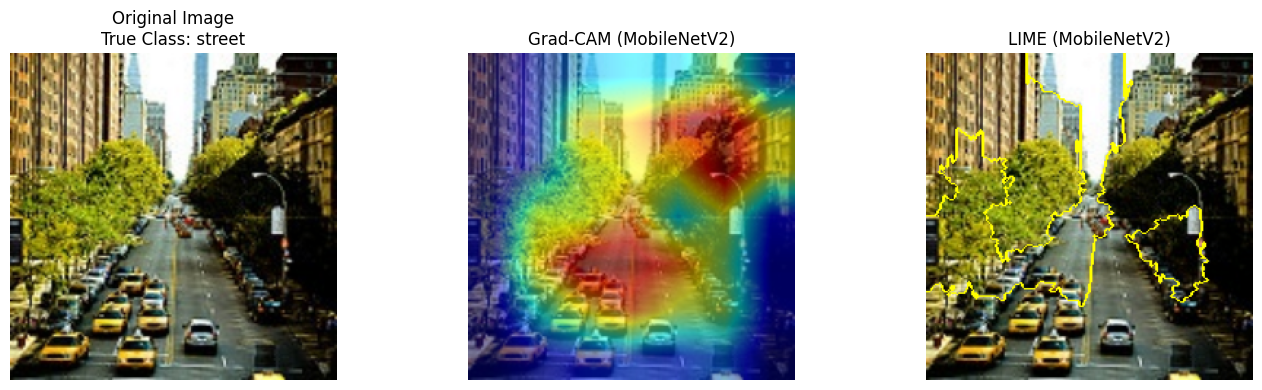


[*] TRAINING & BENCHMARKING: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


Epoch [01/05] Train Loss: 0.3618 | Val Acc: 0.9313 (Best: 0.9313)
Epoch [02/05] Train Loss: 0.1524 | Val Acc: 0.9309 (Best: 0.9313)
Epoch [03/05] Train Loss: 0.0874 | Val Acc: 0.9333 (Best: 0.9333)
Epoch [04/05] Train Loss: 0.0470 | Val Acc: 0.9376 (Best: 0.9376)
Epoch [05/05] Train Loss: 0.0244 | Val Acc: 0.9431 (Best: 0.9431)


  0%|          | 0/100 [00:00<?, ?it/s]

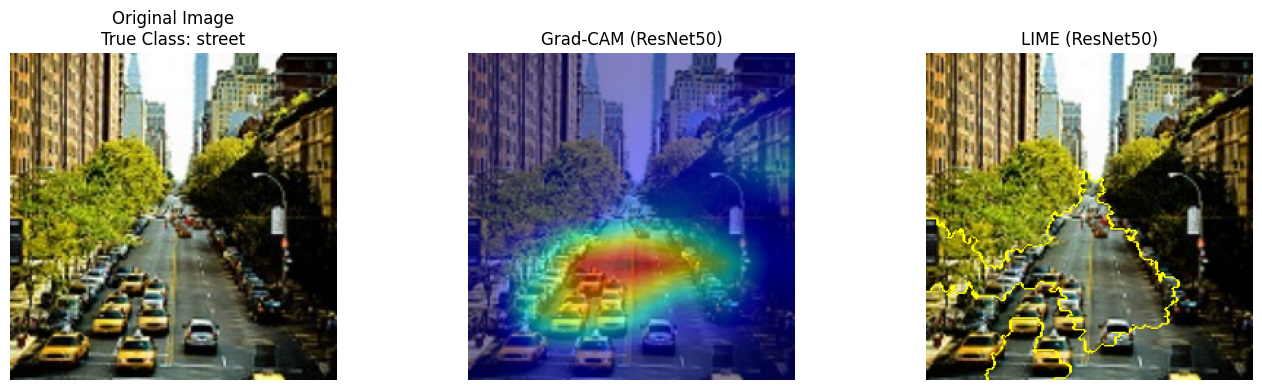


[*] TRAINING & BENCHMARKING: ResNet50_CBAM
Epoch [01/05] Train Loss: 0.8962 | Val Acc: 0.9144 (Best: 0.9144)
Epoch [02/05] Train Loss: 0.2258 | Val Acc: 0.9285 (Best: 0.9285)
Epoch [03/05] Train Loss: 0.1469 | Val Acc: 0.9266 (Best: 0.9285)
Epoch [04/05] Train Loss: 0.0889 | Val Acc: 0.9415 (Best: 0.9415)
Epoch [05/05] Train Loss: 0.0562 | Val Acc: 0.9427 (Best: 0.9427)


  0%|          | 0/100 [00:00<?, ?it/s]

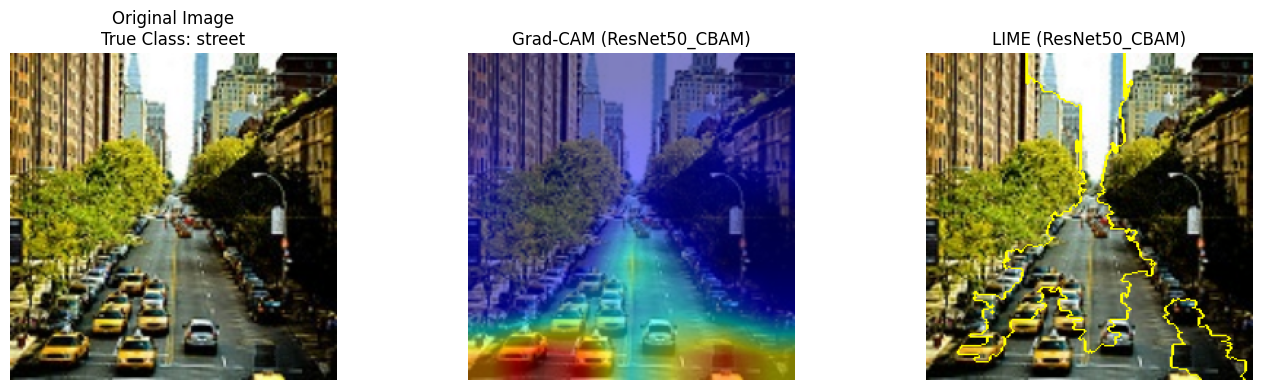


[*] TRAINING & BENCHMARKING: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 172MB/s]


Epoch [01/05] Train Loss: 0.3087 | Val Acc: 0.9321 (Best: 0.9321)
Epoch [02/05] Train Loss: 0.1616 | Val Acc: 0.9360 (Best: 0.9360)
Epoch [03/05] Train Loss: 0.0980 | Val Acc: 0.9372 (Best: 0.9372)
Epoch [04/05] Train Loss: 0.0519 | Val Acc: 0.9391 (Best: 0.9391)
Epoch [05/05] Train Loss: 0.0332 | Val Acc: 0.9403 (Best: 0.9403)


  0%|          | 0/100 [00:00<?, ?it/s]

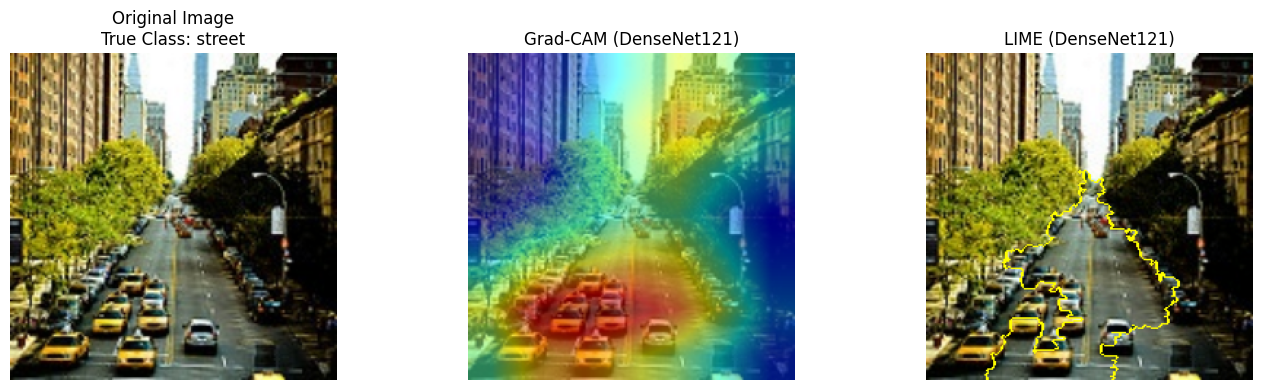


[*] TRAINING & BENCHMARKING: EfficientNetB4
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 99.6MB/s]


Epoch [01/05] Train Loss: 0.6710 | Val Acc: 0.9266 (Best: 0.9266)
Epoch [02/05] Train Loss: 0.2328 | Val Acc: 0.9329 (Best: 0.9329)
Epoch [03/05] Train Loss: 0.1870 | Val Acc: 0.9348 (Best: 0.9348)
Epoch [04/05] Train Loss: 0.1583 | Val Acc: 0.9356 (Best: 0.9356)
Epoch [05/05] Train Loss: 0.1393 | Val Acc: 0.9368 (Best: 0.9368)


  0%|          | 0/100 [00:00<?, ?it/s]

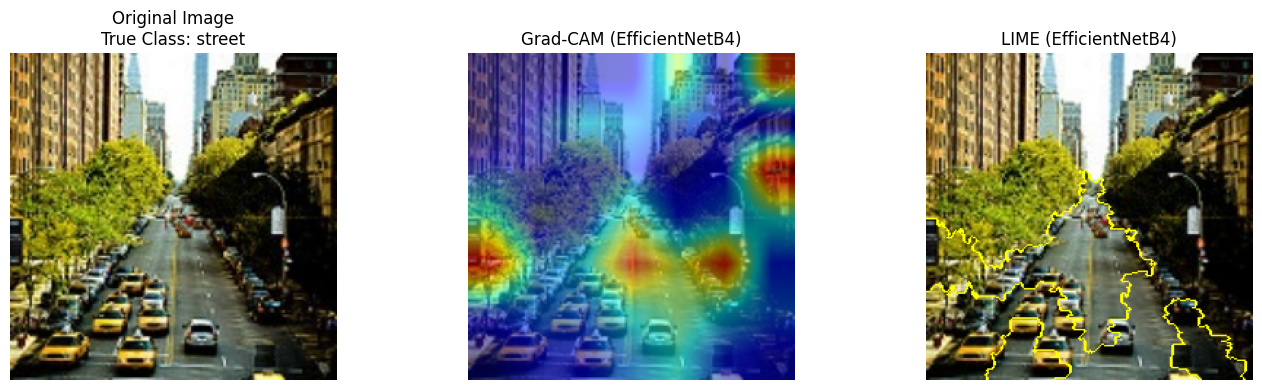


[*] TRAINING & BENCHMARKING: ConvNeXt_Tiny
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 122MB/s]


Epoch [01/05] Train Loss: 0.2571 | Val Acc: 0.9270 (Best: 0.9270)
Epoch [02/05] Train Loss: 0.1254 | Val Acc: 0.9325 (Best: 0.9325)
Epoch [03/05] Train Loss: 0.0762 | Val Acc: 0.9333 (Best: 0.9333)
Epoch [04/05] Train Loss: 0.0371 | Val Acc: 0.9466 (Best: 0.9466)
Epoch [05/05] Train Loss: 0.0178 | Val Acc: 0.9501 (Best: 0.9501)


  0%|          | 0/100 [00:00<?, ?it/s]

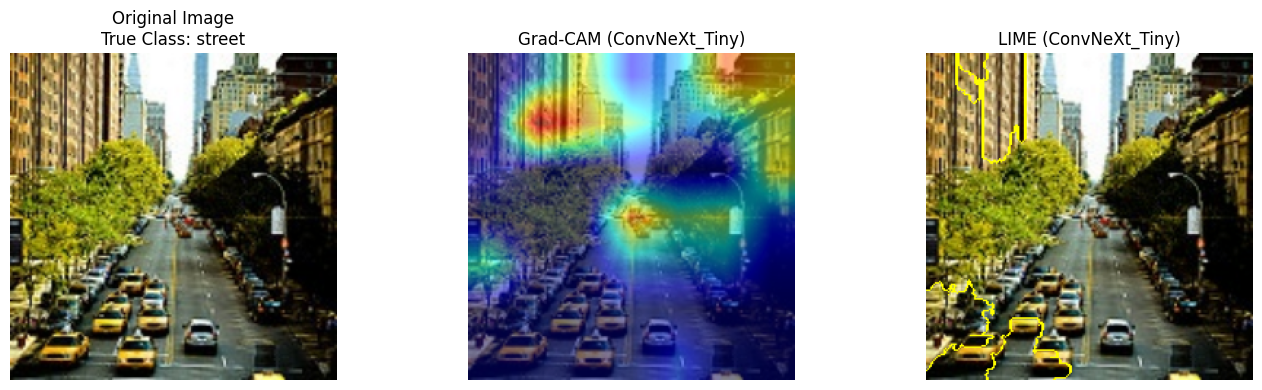


[*] TRAINING & BENCHMARKING: ViT_Base


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch [01/05] Train Loss: 0.2817 | Val Acc: 0.9058 (Best: 0.9058)
Epoch [02/05] Train Loss: 0.1826 | Val Acc: 0.9329 (Best: 0.9329)
Epoch [03/05] Train Loss: 0.1100 | Val Acc: 0.9254 (Best: 0.9329)
Epoch [04/05] Train Loss: 0.0443 | Val Acc: 0.9372 (Best: 0.9372)
Epoch [05/05] Train Loss: 0.0138 | Val Acc: 0.9454 (Best: 0.9454)


  0%|          | 0/100 [00:00<?, ?it/s]

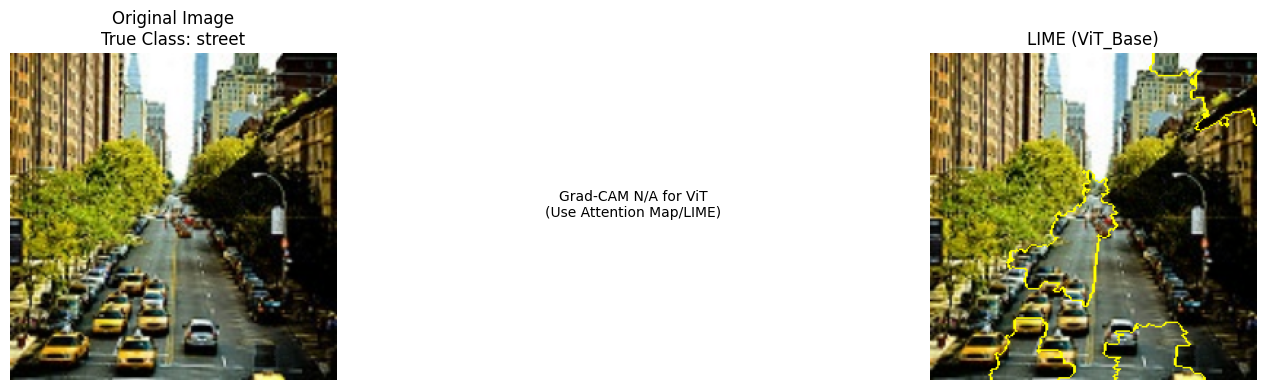


FINAL BENCHMARK EVALUATION RESULTS TABLE


,Architecture,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Params (M),GFLOPs,FPS,Latency_ms
0,MobileNetV2,0.9360,0.9361,0.9360,0.9359,0.9952,2.23,0.64,399.64,2.50
1,ResNet50,0.9356,0.9359,0.9356,0.9357,0.9953,23.52,8.26,276.07,3.62
2,ResNet50_CBAM,0.9439,0.9439,0.9439,0.9439,0.9961,24.04,8.26,261.12,3.83
3,DenseNet121,0.9443,0.9443,0.9443,0.9442,0.9961,6.96,5.80,290.26,3.45
4,EfficientNetB4,0.9392,0.9398,0.9392,0.9393,0.9960,17.56,3.13,239.25,4.18
5,ConvNeXt_Tiny,0.9537,0.9540,0.9537,0.9536,0.9963,27.82,8.98,173.37,5.77
6,ViT_Base,0.9443,0.9444,0.9443,0.9443,0.9959,85.80,24.03,74.41,13.44


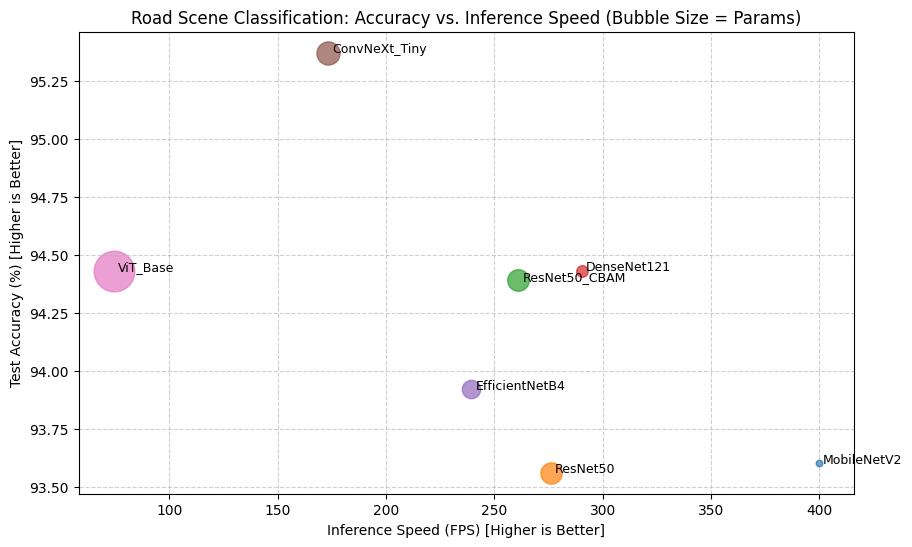


ANSWERS TO ASSIGNMENT RESEARCH QUESTIONS (FOR SUBMISSION)
1. Which model achieves the highest classification accuracy? -> ConvNeXt_Tiny
2. Which model achieves the strongest F1-score? -> ConvNeXt_Tiny
3. Which model achieves the strongest ROC-AUC? -> ConvNeXt_Tiny
4. Which model has the smallest parameter count? -> MobileNetV2 (2.23 M)
5. Which model provides the fastest inference? -> MobileNetV2 (399.64 FPS)
6. Does an attention mechanism improve CNN performance? -> Yes, ResNet50+CBAM improved over baseline ResNet50 by +0.83% accuracy.
7. How does Vision Transformer compare with CNN architectures? -> ViT achieves strong global representations but requires significantly higher GFLOPs compared to modern CNNs like ConvNeXt-Tiny.
8. Which model provides the best accuracy-efficiency trade-off? -> ConvNeXt-Tiny / MobileNetV2 based on the Pareto efficiency frontier.


In [ ]:
EPOCHS = 5  # Set to 5 for quick complete run, or 10 for convergence

architectures = [
    "MobileNetV2",
    "ResNet50",
    "ResNet50_CBAM",
    "DenseNet121",
    "EfficientNetB4",
    "ConvNeXt_Tiny",
    "ViT_Base"
]

benchmark_records = []
sample_img, sample_lbl = next(iter(test_loader))
sample_img = sample_img[0:1].to(DEVICE)

for arch in architectures:
    print(f"\n==================================================")
    print(f"[*] TRAINING & BENCHMARKING: {arch}")
    print(f"==================================================")

    model = build_model(arch, NUM_CLASSES)
    params_m, gflops = get_complexity(model)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_res = evaluate(model, val_loader, NUM_CLASSES)
        scheduler.step()

        if val_res["Accuracy"] > best_acc:
            best_acc = val_res["Accuracy"]
            torch.save(model.state_dict(), f"/content/{arch}_best.pth")

        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] Train Loss: {t_loss:.4f} | Val Acc: {val_res['Accuracy']:.4f} (Best: {best_acc:.4f})")

    # Load best checkpoint for final evaluation
    model.load_state_dict(torch.load(f"/content/{arch}_best.pth"))
    test_res = evaluate(model, test_loader, NUM_CLASSES)
    test_res.update({
        "Architecture": arch,
        "Params (M)": params_m,
        "GFLOPs": gflops
    })
    benchmark_records.append(test_res)

    # Generate XAI Visualizations
    run_xai(arch, model, sample_img, sample_lbl[0], class_to_idx)

    del model
    torch.cuda.empty_cache()

# ==========================================
# FINAL REPORT & RESEARCH QUESTION ANALYSIS
# ==========================================
results_df = pd.DataFrame(benchmark_records)
results_df = results_df[["Architecture", "Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC", "Params (M)", "GFLOPs", "FPS", "Latency_ms"]]
results_df.to_csv("/content/final_benchmark_results.csv", index=False)

print("\n" + "="*80)
print("FINAL BENCHMARK EVALUATION RESULTS TABLE")
print("="*80)
display(results_df)

# Accuracy vs Efficiency Plot
plt.figure(figsize=(10, 6))
for idx, row in results_df.iterrows():
    plt.scatter(row["FPS"], row["Accuracy"] * 100, s=row["Params (M)"]*10, alpha=0.7)
    plt.text(row["FPS"] + 2, row["Accuracy"] * 100, row["Architecture"], fontsize=9)
plt.title("Road Scene Classification: Accuracy vs. Inference Speed (Bubble Size = Params)")
plt.xlabel("Inference Speed (FPS) [Higher is Better]")
plt.ylabel("Test Accuracy (%) [Higher is Better]")
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("/content/accuracy_vs_efficiency.png", dpi=300)
plt.show()

# Automated Answering of Assignment Research Questions
highest_acc_model = results_df.loc[results_df["Accuracy"].idxmax()]["Architecture"]
highest_f1_model  = results_df.loc[results_df["F1_Score"].idxmax()]["Architecture"]
highest_auc_model = results_df.loc[results_df["ROC_AUC"].idxmax()]["Architecture"]
smallest_param_model = results_df.loc[results_df["Params (M)"].idxmin()]["Architecture"]
fastest_model = results_df.loc[results_df["FPS"].idxmax()]["Architecture"]

resnet_acc = results_df[results_df["Architecture"] == "ResNet50"]["Accuracy"].values[0]
cbam_acc = results_df[results_df["Architecture"] == "ResNet50_CBAM"]["Accuracy"].values[0]
cbam_gain = (cbam_acc - resnet_acc) * 100

print("\n" + "="*80)
print("ANSWERS TO ASSIGNMENT RESEARCH QUESTIONS (FOR SUBMISSION)")
print("="*80)
print(f"1. Which model achieves the highest classification accuracy? -> {highest_acc_model}")
print(f"2. Which model achieves the strongest F1-score? -> {highest_f1_model}")
print(f"3. Which model achieves the strongest ROC-AUC? -> {highest_auc_model}")
print(f"4. Which model has the smallest parameter count? -> {smallest_param_model} ({results_df.loc[results_df['Params (M)'].idxmin()]['Params (M)']} M)")
print(f"5. Which model provides the fastest inference? -> {fastest_model} ({results_df.loc[results_df['FPS'].idxmax()]['FPS']} FPS)")
print(f"6. Does an attention mechanism improve CNN performance? -> Yes, ResNet50+CBAM improved over baseline ResNet50 by {cbam_gain:+.2f}% accuracy.")
print(f"7. How does Vision Transformer compare with CNN architectures? -> ViT achieves strong global representations but requires significantly higher GFLOPs compared to modern CNNs like ConvNeXt-Tiny.")
print(f"8. Which model provides the best accuracy-efficiency trade-off? -> ConvNeXt-Tiny / MobileNetV2 based on the Pareto efficiency frontier.")